In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate

In [ ]:
sys.path.insert(0, '../../exploration/run_ppxf/')
sys.path

from model_processing import MilesAgeMhAlpha

model = MilesAgeMhAlpha()
model.load('../../data/models/MILES_BASTI_KB_Ep0.00')
model.build_name_grid()
model.build_flux_grid()
model.build_head_grid()

In [67]:
path_ml_miles = '../../data/models/UBBVRIJHK_kb_iTp0.00.MAG'

ml_miles = pd.read_table(path_ml_miles, sep=' ')
ml_miles

,model,mu,Z,Age,M(*+remn),U_Buser,B2_Buser,B3_Buser,V_Buser,R_Cousins,...,K_Johnson,ML(U_Buser),ML(B2_Buser),ML(B3_Buser),ML(V_Buser),ML(R_Cousins),ML(I_Cousins),ML(J_Johnson),ML(H_Bessell),ML(K_Johnson)
0,Ekb1.30Zm2.27T00.0300_iTp0.00_baseFe.fits,1.3,-2.27,0.03,0.8736,1.69515,2.48602,2.47598,2.66670,-99.00000,...,-99.00000,0.02395,0.05745,0.05693,0.12022,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
1,Ekb1.30Zm2.27T00.0400_iTp0.00_baseFe.fits,1.3,-2.27,0.04,0.8617,1.92945,2.65645,2.64733,2.81522,-99.00000,...,-99.00000,0.02932,0.06630,0.06575,0.13597,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
2,Ekb1.30Zm2.27T00.0500_iTp0.00_baseFe.fits,1.3,-2.27,0.05,0.8528,2.11057,2.79569,2.78717,2.93902,-99.00000,...,-99.00000,0.03428,0.07460,0.07401,0.15082,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
3,Ekb1.30Zm2.27T00.0600_iTp0.00_baseFe.fits,1.3,-2.27,0.06,0.8528,2.24094,2.88750,2.87957,3.01557,-99.00000,...,-99.00000,0.03866,0.08118,0.08059,0.16184,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
4,Ekb1.30Zm2.27T00.0700_iTp0.00_baseFe.fits,1.3,-2.27,0.07,0.8404,2.36371,2.98337,2.97610,3.08903,-99.00000,...,-99.00000,0.04265,0.08738,0.08680,0.17065,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,Ekb1.30Zp0.40T12.0000_iTp0.00_baseFe.fits,1.3,0.40,12.00,0.6933,9.10542,8.35608,8.39775,7.39875,6.78831,...,4.07174,17.50201,10.16135,10.55893,7.45457,5.92444,4.18047,2.27422,1.55561,1.36779
632,Ekb1.30Zp0.40T12.5000_iTp0.00_baseFe.fits,1.3,0.40,12.50,0.6925,9.15438,8.39575,8.43769,7.43377,6.82061,...,4.09762,18.28828,10.52741,10.94193,7.69003,6.09627,4.29170,2.32770,1.59192,1.39916
633,Ekb1.30Zp0.40T13.0000_iTp0.00_baseFe.fits,1.3,0.40,13.00,0.6917,9.20256,8.43414,8.47631,7.46777,6.85223,...,4.12309,19.09593,10.89366,11.32508,7.92549,6.26919,4.40298,2.37624,1.62773,1.43072
634,Ekb1.30Zp0.40T13.5000_iTp0.00_baseFe.fits,1.3,0.40,13.50,0.6910,9.25115,8.47167,8.51411,7.50088,6.88245,...,4.14841,19.94976,11.26537,11.71449,8.16262,6.43958,4.51413,2.43017,1.66479,1.46299


In [ ]:
ml_miles[['Z', 'Age', 'ML(V_Buser)']]

In [ ]:
grid = ml_miles.pivot(index="Z", columns="Age", values='ML(V_Buser)')
mh_range = grid.index.to_numpy().round(2)
age_range = grid.columns.to_numpy().round(2)

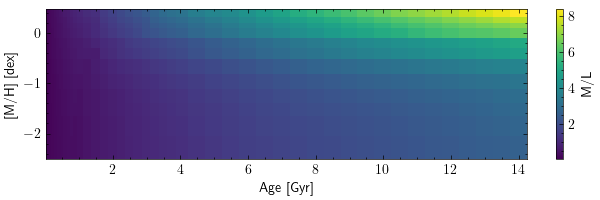

In [66]:
%matplotlib widget
import matplotlib.colors as colors

with plt.style.context('science'):
    fig, ax = plt.subplots(1, 1, figsize=(6, 2), constrained_layout=True)
    cmap = 'viridis'

    im0 = ax.pcolor(age_range, mh_range, grid, cmap=cmap)
    cbar0 = fig.colorbar(im0, ax=ax)
    
    ax.set_xlabel('Age [Gyr]')
    ax.set_ylabel('[M/H] [dex]')
    cbar0.set_label('M/L')
    